# Поиск рядов с пересекающимися аномальными интервалами

Демо для мультиряда из `time_series_examples/multivariate/time_series_0.csv`: выбираем query-отрезок в одном канале, детектируем аномальные точки по каждому каналу отдельно, собираем соседние точки в интервалы, мерджим маленькие разрывы и считаем метрики пересечения с query-интервалами.

In [38]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from anomaly_detection import AnomalyDetectionSystem, AnomalyIntervalOverlapSearch

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 120)

## Загрузка мультиряда

In [39]:
DATA_PATH = Path("time_series_examples/multivariate/time_series_0.csv")

time_series = pd.read_csv(DATA_PATH)
time_series["timestamp"] = pd.to_datetime(time_series["timestamp"], unit="ms")
time_series = time_series.set_index("timestamp")

print(time_series.shape)
print(time_series.index.min(), "->", time_series.index.max())
time_series.head()

(9504, 8)
2025-09-10 13:55:00 -> 2025-10-13 13:50:00


,value_0,value_1,value_2,value_3,value_4,value_5,value_6,value_7
timestamp,,,,,,,,
2025-09-10 13:55:00,35.857143,39.857143,3.333333,35.851852,5.756098,4.000000,32.307692,56.000000
2025-09-10 14:00:00,36.521739,39.857143,3.276596,35.866667,5.894737,4.000000,33.200000,55.652174
2025-09-10 14:05:00,36.869565,39.636364,3.363636,35.047619,6.181818,3.666667,32.181818,55.578947
2025-09-10 14:10:00,34.428571,39.058824,3.250000,34.451613,6.100000,4.571429,32.000000,53.263158
2025-09-10 14:15:00,34.545455,38.206897,3.304348,33.846154,5.951220,3.935484,31.393939,52.000000


## Query-отрезок и параметры поиска

В качестве query-ряда используем `value_0`. Окно выбрано вокруг аномального участка из этого ряда; при необходимости можно заменить `QUERY_SERIES`, `QUERY_START` и `QUERY_END`.

In [40]:
DETECTOR_CONFIG = {
    "detection_model_params": {
        "model_name": "Autoregressive Dev",
        "order": 20,
        "threshold": 3.0,
        "stable": True,
    }
}

QUERY_SERIES = "value_0"
QUERY_START = pd.Timestamp("2025-09-23 10:25:00")
QUERY_END = pd.Timestamp("2025-09-23 14:05:00")

system = AnomalyDetectionSystem(**DETECTOR_CONFIG)
searcher = AnomalyIntervalOverlapSearch(
    system,
    max_gap=3,
    min_points=3,
    metric_weights={"f1": 0.0, "iou": 1.0, "recall": 0.0, "precision": 0.0},
    overlap_threshold=0.70,
    required_metrics={"recall": 0.50},
)

result = searcher.search(
    time_series,
    query_series=QUERY_SERIES,
    start_time=QUERY_START,
    end_time=QUERY_END,
)

result.to_frame(include_query=True)

,series_name,is_query,matched,score,recall,precision,iou,f1,overlap_points,query_points,candidate_points,union_points,n_intervals,intervals
0,value_0,True,True,1.000000,1.000000,1.000000,1.000000,1.000000,29,29,29,29,2,2025-09-23 11:25:00 - 2025-09-23 13:05:00; 2025-09-23 13:30:00 - 2025-09-23 14:05:00
1,value_1,False,True,0.878788,1.000000,0.878788,0.878788,0.935484,29,29,33,33,1,2025-09-23 11:25:00 - 2025-09-23 14:05:00
2,value_2,False,True,0.878788,1.000000,0.878788,0.878788,0.935484,29,29,33,33,1,2025-09-23 11:25:00 - 2025-09-23 14:05:00
3,value_3,False,True,0.878788,1.000000,0.878788,0.878788,0.935484,29,29,33,33,1,2025-09-23 11:25:00 - 2025-09-23 14:05:00
4,value_4,False,True,0.878788,1.000000,0.878788,0.878788,0.935484,29,29,33,33,1,2025-09-23 11:25:00 - 2025-09-23 14:05:00
5,value_5,False,True,0.878788,1.000000,0.878788,0.878788,0.935484,29,29,33,33,1,2025-09-23 11:25:00 - 2025-09-23 14:05:00
6,value_7,False,True,0.818182,0.931034,0.870968,0.818182,0.900000,27,29,31,33,1,2025-09-23 11:25:00 - 2025-09-23 13:55:00
7,value_6,False,True,0.783784,1.000000,0.783784,0.783784,0.878788,29,29,37,37,1,2025-09-23 11:05:00 - 2025-09-23 14:05:00


## Query-отрезок и его аномальные интервалы

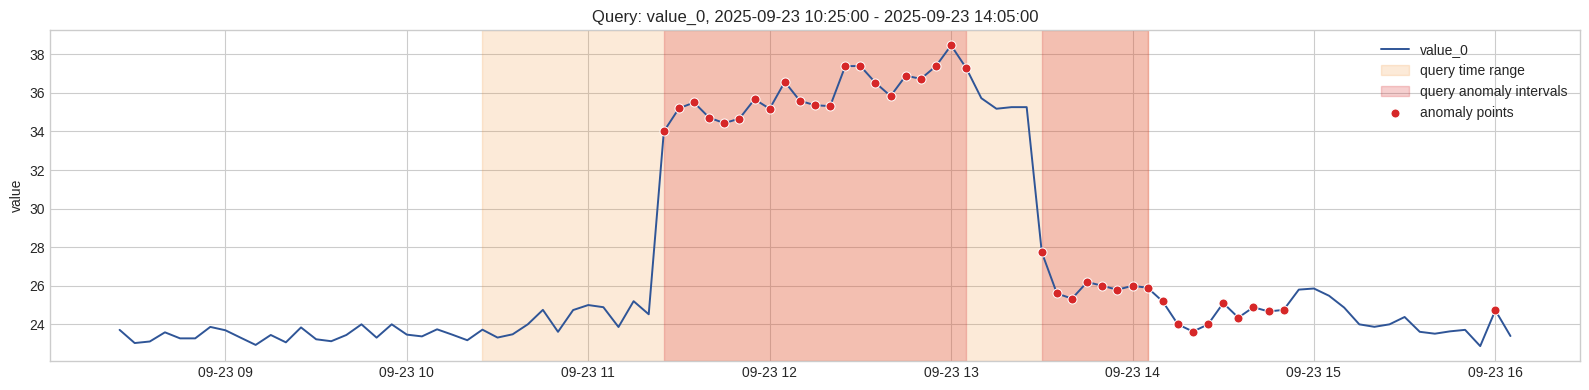

In [41]:
def add_interval_spans(ax, intervals, color, label, alpha=0.25):
    used_label = False
    for interval in intervals:
        ax.axvspan(
            interval.start,
            interval.end,
            color=color,
            alpha=alpha,
            label=label if not used_label else None,
        )
        used_label = True


def anomaly_points(column, start, end, source=None):
    source = time_series[column] if source is None else source
    mask = pd.Series(result.detections[column].is_anomaly.astype(bool), index=time_series.index)
    values = source.loc[start:end]
    return values[mask.loc[start:end].reindex(values.index, fill_value=False)]


def add_anomaly_points(ax, points, color, label="anomaly points", size=36):
    if points.empty:
        return
    ax.scatter(
        points.index,
        points.values,
        s=size,
        color=color,
        edgecolor="white",
        linewidth=0.7,
        zorder=6,
        label=label,
    )


context_start = QUERY_START - pd.Timedelta(hours=2)
context_end = QUERY_END + pd.Timedelta(hours=2)
query_context = time_series.loc[context_start:context_end, QUERY_SERIES]
query_anomaly_points = anomaly_points(QUERY_SERIES, context_start, context_end)

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(query_context.index, query_context.values, color="#2f5597", linewidth=1.4, label=QUERY_SERIES)
ax.axvspan(QUERY_START, QUERY_END, color="#f28e2b", alpha=0.18, label="query time range")
add_interval_spans(ax, result.query_intervals, color="#d62728", label="query anomaly intervals", alpha=0.22)
add_anomaly_points(ax, query_anomaly_points, color="#d62728", label="anomaly points", size=42)
ax.set_title(f"Query: {QUERY_SERIES}, {QUERY_START} - {QUERY_END}")
ax.set_ylabel("value")
ax.legend(loc="upper right")
plt.tight_layout()

## Аномальные интервалы во всех рядах

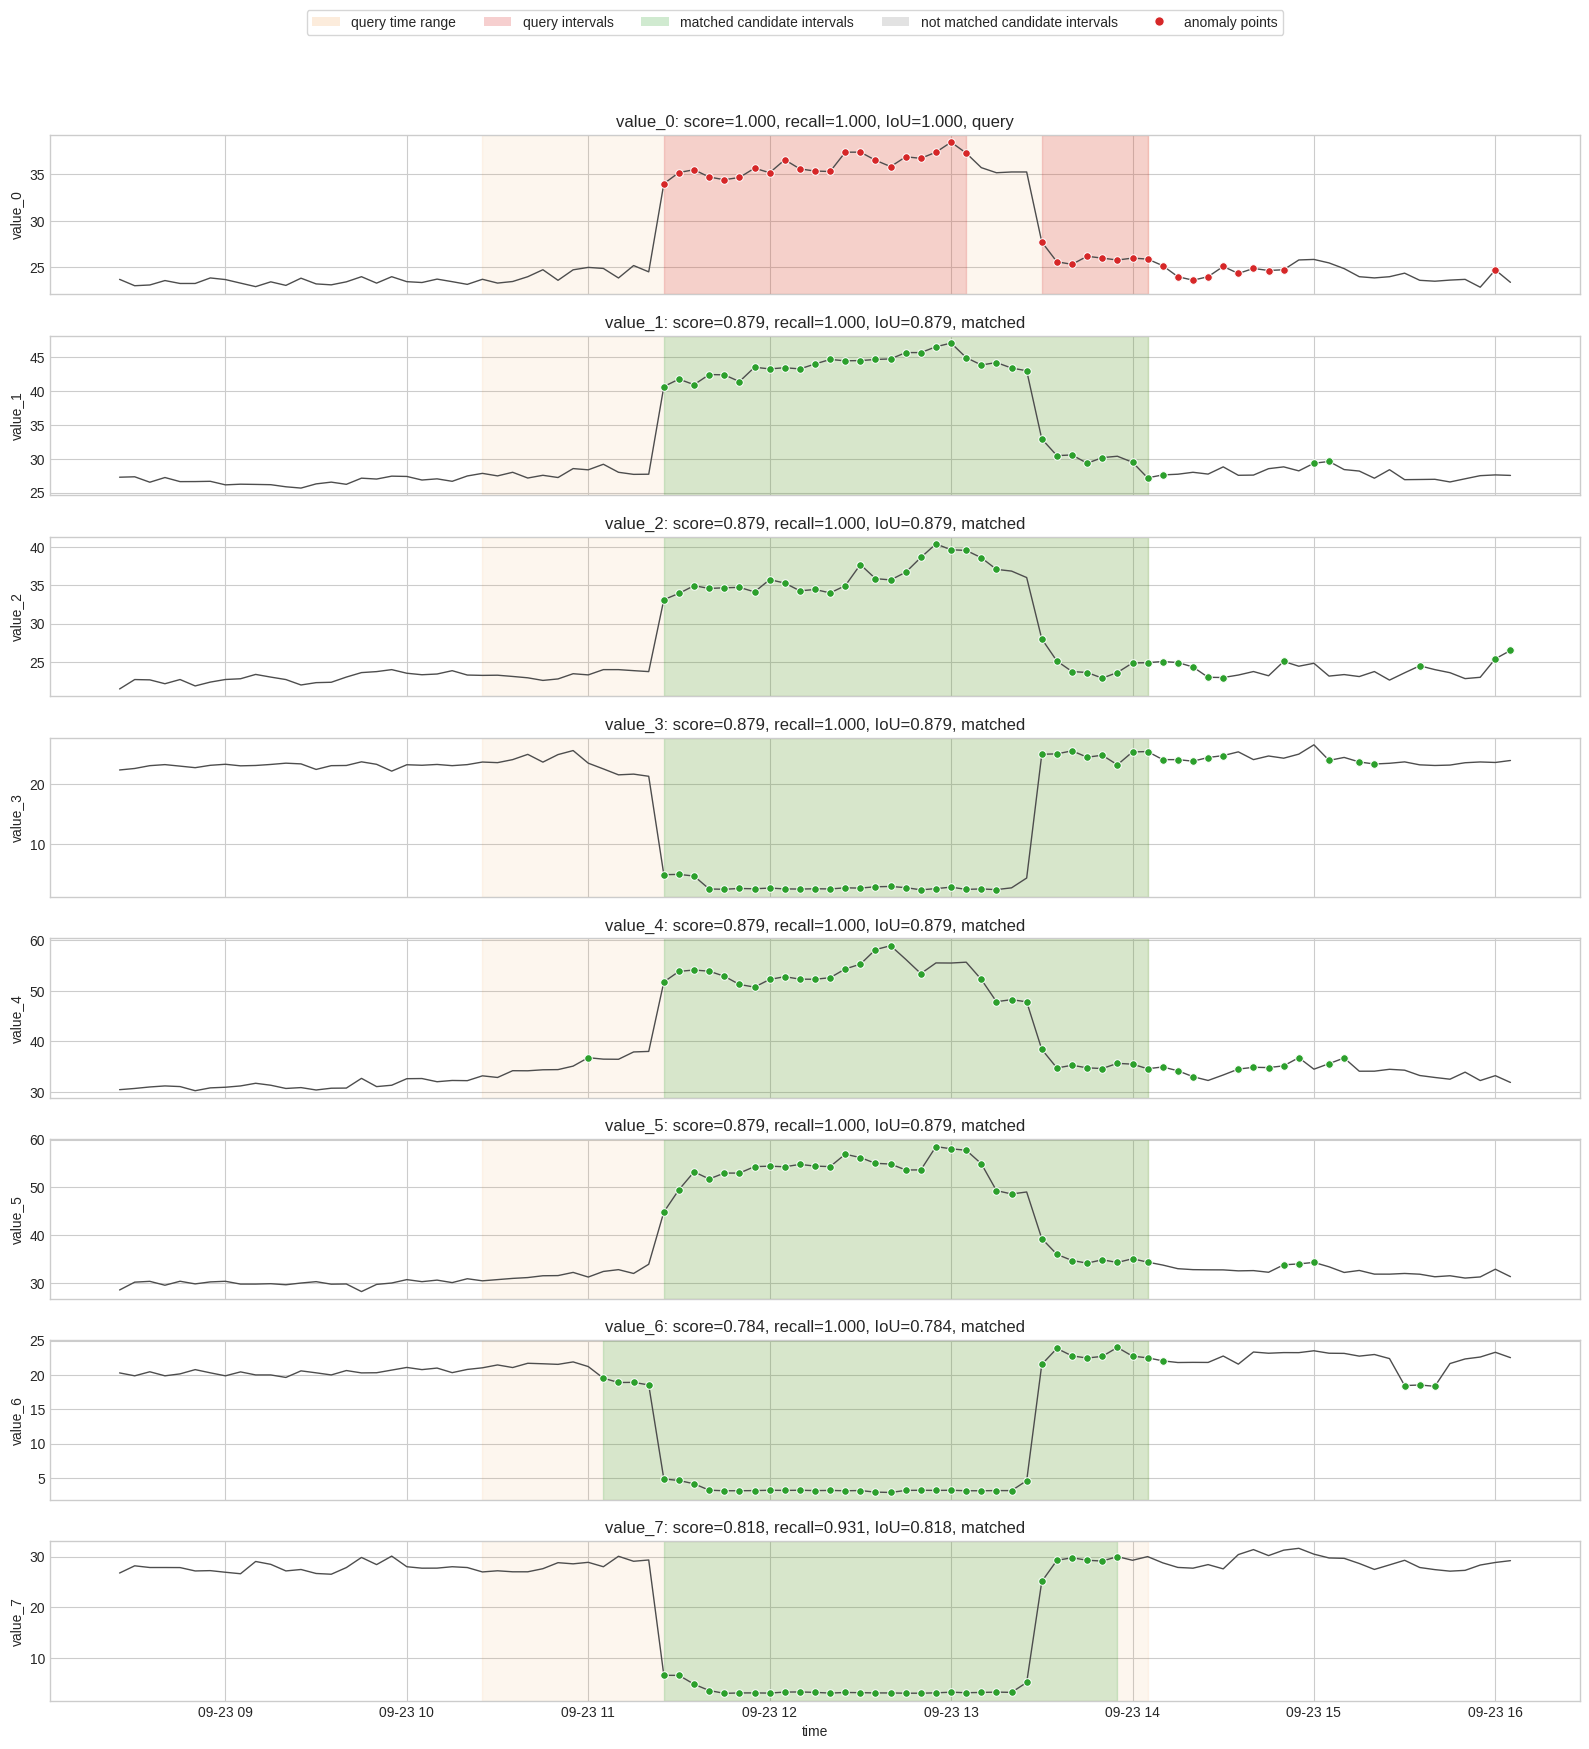

In [42]:
fig, axes = plt.subplots(
    len(time_series.columns),
    1,
    figsize=(16, 2.2 * len(time_series.columns)),
    sharex=True,
)
axes = np.atleast_1d(axes)

for ax, column in zip(axes, time_series.columns):
    match = result.series_matches[column]
    series_context = time_series.loc[context_start:context_end, column]

    if match.is_query:
        interval_color = "#d62728"
        status = "query"
    elif match.matched:
        interval_color = "#2ca02c"
        status = "matched"
    else:
        interval_color = "#7f7f7f"
        status = "not matched"

    points = anomaly_points(column, context_start, context_end)

    ax.plot(series_context.index, series_context.values, color="#4d4d4d", linewidth=1.0)
    ax.axvspan(QUERY_START, QUERY_END, color="#f28e2b", alpha=0.08)
    add_interval_spans(ax, match.intervals, color=interval_color, label=status, alpha=0.18)
    add_anomaly_points(ax, points, color=interval_color, size=30)
    ax.set_ylabel(column)
    ax.set_title(f"{column}: score={match.score:.3f}, recall={match.metrics.recall:.3f}, IoU={match.metrics.iou:.3f}, {status}")

axes[-1].set_xlabel("time")
legend_handles = [
    Patch(facecolor="#f28e2b", alpha=0.16, label="query time range"),
    Patch(facecolor="#d62728", alpha=0.22, label="query intervals"),
    Patch(facecolor="#2ca02c", alpha=0.22, label="matched candidate intervals"),
    Patch(facecolor="#7f7f7f", alpha=0.22, label="not matched candidate intervals"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#d62728", markeredgecolor="white", markersize=7, label="anomaly points"),
]
fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.995),
    ncol=5,
    frameon=True,
)
fig.tight_layout(rect=(0, 0, 1, 0.94))

## Совместный вид найденных рядов

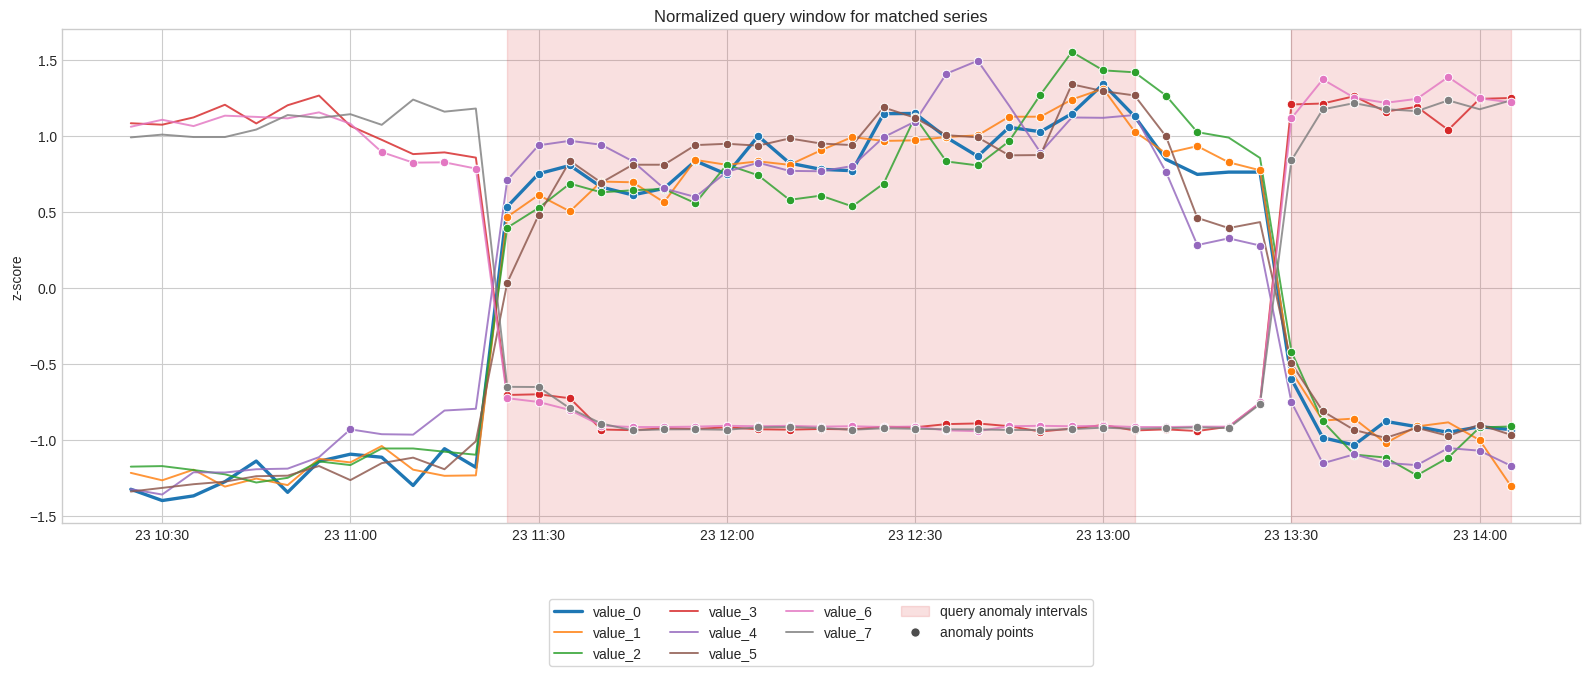

In [43]:
matched_columns = [QUERY_SERIES, *result.matching_series]
window = time_series.loc[QUERY_START:QUERY_END, matched_columns]
normalized = (window - window.mean()) / (window.std(ddof=0) + 1e-8)

fig, ax = plt.subplots(figsize=(16, 8))
for column in normalized.columns:
    linewidth = 2.4 if column == QUERY_SERIES else 1.4
    alpha = 1.0 if column == QUERY_SERIES else 0.82
    line = ax.plot(normalized.index, normalized[column], linewidth=linewidth, alpha=alpha, label=column)[0]
    points = anomaly_points(column, QUERY_START, QUERY_END, source=normalized[column])
    add_anomaly_points(ax, points, color=line.get_color(), label="_nolegend_", size=38)

add_interval_spans(ax, result.query_intervals, color="#d62728", label="query anomaly intervals", alpha=0.14)
ax.set_title("Normalized query window for matched series")
ax.set_ylabel("z-score")
handles, labels = ax.get_legend_handles_labels()
handles.append(
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor="#4d4d4d",
        markeredgecolor="white",
        markersize=7,
        label="anomaly points",
    )
)
labels.append("anomaly points")
ax.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=4, frameon=True)
fig.tight_layout(rect=(0, 0.12, 1, 1))

## Итоговые ряды, прошедшие threshold

In [44]:
result.to_frame(matched_only=True)

,series_name,is_query,matched,score,recall,precision,iou,f1,overlap_points,query_points,candidate_points,union_points,n_intervals,intervals
0,value_1,False,True,0.878788,1.000000,0.878788,0.878788,0.935484,29,29,33,33,1,2025-09-23 11:25:00 - 2025-09-23 14:05:00
1,value_2,False,True,0.878788,1.000000,0.878788,0.878788,0.935484,29,29,33,33,1,2025-09-23 11:25:00 - 2025-09-23 14:05:00
2,value_3,False,True,0.878788,1.000000,0.878788,0.878788,0.935484,29,29,33,33,1,2025-09-23 11:25:00 - 2025-09-23 14:05:00
3,value_4,False,True,0.878788,1.000000,0.878788,0.878788,0.935484,29,29,33,33,1,2025-09-23 11:25:00 - 2025-09-23 14:05:00
4,value_5,False,True,0.878788,1.000000,0.878788,0.878788,0.935484,29,29,33,33,1,2025-09-23 11:25:00 - 2025-09-23 14:05:00
5,value_7,False,True,0.818182,0.931034,0.870968,0.818182,0.900000,27,29,31,33,1,2025-09-23 11:25:00 - 2025-09-23 13:55:00
6,value_6,False,True,0.783784,1.000000,0.783784,0.783784,0.878788,29,29,37,37,1,2025-09-23 11:05:00 - 2025-09-23 14:05:00
